In [ ]:
from pathlib import Path
import pickle as pkl

import matplotlib.pyplot as plt
import numpy as np

In [35]:
dirpath_res = Path(r'D:\WORK\Salvador\repo\model_tuner\test_data\range_search'
                   r'\subnet_state1_mech1_nosub_wmult_0.1\ngf_tcalc_5_10\info')

res = []
for n in range(1, 6):
    print(n)
    fpath_res = dirpath_res / f'iter_rates_{n}.pkl'
    with open(fpath_res, 'rb') as fid:
        res.append(pkl.load(fid))

1
2
3
4
5


In [36]:
res[-1]['NGF1'].ou_mean.values

array([-0.05283966, -0.03746372, -0.02208778, -0.00671184,  0.0086641 ])

In [43]:
import numpy as np
c = np.round((10.113, 20.223), 2)
c1, c2 = c
print(c1, c2)
type(c1)

10.11 20.22


numpy.float64

In [13]:
import numpy as np

pop = 'PV2'

ou_mean = []
rr = []

for n in range(4):
    x = res[n][pop].isel(ou_std=0)
    ou_mean += x.ou_mean.values.tolist()
    rr += x.values.tolist()

ou_mean = np.array(ou_mean)
rr = np.array(rr)

(0.0, 50.0)

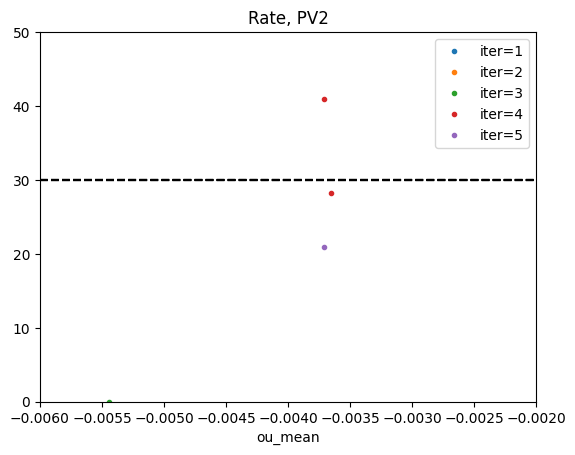

In [25]:
import matplotlib.pyplot as plt
import numpy as np

pop = 'PV2'

plt.figure()
for n in range(5):
    x = res[n][pop].isel(ou_std=0)
    ou_mean_ = x.ou_mean.values
    rr_ = x.values
    plt.plot(ou_mean_, rr_ + n * 0, '.', label=f'iter={n + 1}')
    plt.axhline(y=30, color='k', linestyle='--')
plt.xlabel('ou_mean')
plt.legend()
plt.title(f'Rate, {pop}')
plt.xlim(-0.006, -0.002)
plt.ylim(0, 50)

In [ ]:
#exp_name = 'vip'
exp_name = 'L46_tcalc_5_10'

iter = 1

fpath_in = Path(r'D:\WORK\Salvador\repo\model_tuner\test_data\range_search'
                rf'\exp_subnet_state1_mech1_nosub_wmult_0.25\{exp_name}\range_tuner_iters'
                rf'\iter_{iter}.pkl')
with open(fpath_in, 'rb') as fid:
    range_tuner = pkl.load(fid)
range_tuner

In [46]:
range_tuner._rates[pop].values[:, 0]

array([ 0.        ,  0.        ,  0.        , 23.17601586,  0.        ])

In [55]:
exp_name = 'vip'
#exp_name = 'L46_tcalc_5_10'

range_tuners = {}
for iter in range(1, 11):
    fpath_in = Path(r'D:\WORK\Salvador\repo\model_tuner\test_data\range_search'
                    rf'\exp_subnet_state1_mech1_nosub_wmult_0.25\{exp_name}\range_tuner_iters'
                    rf'\iter_{iter}.pkl')
    with open(fpath_in, 'rb') as fid:
        range_tuners[iter] = pkl.load(fid)

In [54]:
pop = 'VIP2'
#pop = 'CT6'

n_iter = len(range_tuners)
n_pts = 5

X = np.zeros((n_iter, n_pts))
F1, F2 = X.copy(), X.copy()

for n, range_tuner in enumerate(range_tuners.values()):
    X[n, :] = range_tuner._rates[pop].ou_mean.values
    F1[n, :] = range_tuner._rates[pop].values[:, 0]
    F2[n, :] = range_tuner._rates[pop].values[:, 1]

(-0.025, 0.01)

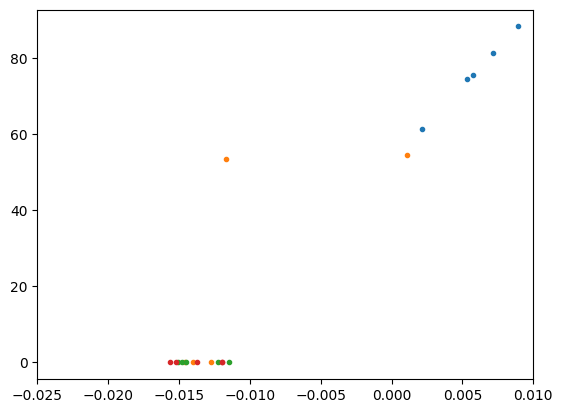

In [62]:
plt.figure()
for n in range(2, 6):
    plt.plot(X[n, :], F1[n, :], '.')
plt.xlim(-0.025, 0.01)

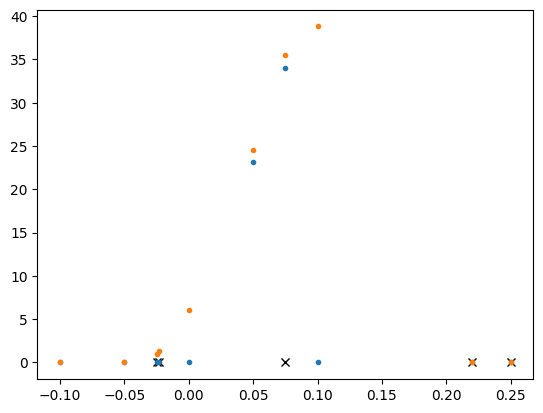

In [ ]:
pop = 'VIP2'
#pop = 'CT6'

range_tuner = range_tuners[2]

f = range_tuner._finders[pop]

idx = np.argsort(f._X)
x = np.asarray(f._X)[idx]
f1 = np.asarray(f._F1)[idx]
f2 = np.asarray(f._F2)[idx]
l = np.asarray(f._L)[idx]

x_ = range_tuner._ou_mean_vals[pop]

plt.figure()
plt.plot(x_, 0 * x_, 'kx')#, markersize=12)
plt.plot(x[idx], f1[idx], '.')
plt.plot(x[idx], f2[idx], '.')
#plt.xlim(-0.025, 0.01)

In [8]:
2500 * 26 / 27.5


2363.6363636363635